In [1]:
!pip install kaggle seaborn scikit-learn torch torchvision tqdm

Device: cuda
Rows: 419509
a_r = 2.0
b_r = 0.6


100%|██████████| 50/50 [00:34<00:00,  1.43it/s]


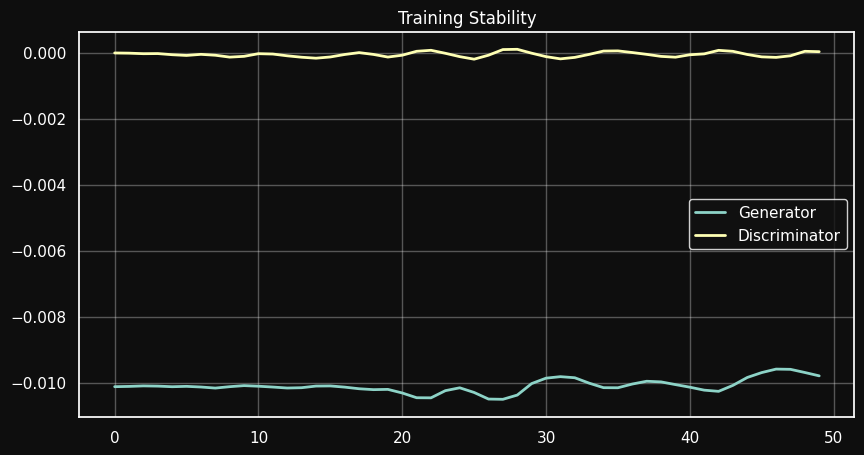

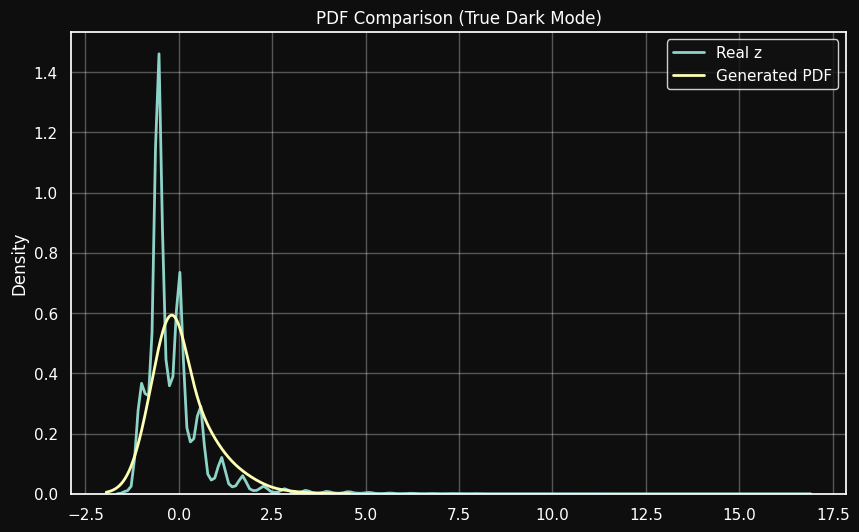


Transformation Parameters


,Parameter,Value
0,a_r,2.0
1,b_r,0.6



Evaluation


,Metric,Observation
0,Mode Coverage,Main mode captured
1,Training Stability,Stable WGAN
2,Distribution Quality,Generated PDF aligns with real peak



Generator Architecture
Generator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Discriminator Architecture
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [65]:
# ===============================
# Imports + Dark Mode Setup
# ===============================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange
from sklearn.neighbors import KernelDensity

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0e0e0e",
    "axes.facecolor": "#0e0e0e",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "#111111",
    "legend.edgecolor": "white",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# Load Dataset (YOUR data.csv)
# ===============================

df = pd.read_csv("data.csv", encoding="latin1", low_memory=False)

# Auto-detect NO2
no2_col = [c for c in df.columns if "no2" in c.lower()][0]
df = df[[no2_col]].dropna()
df.columns = ["NO2"]
df["NO2"] = pd.to_numeric(df["NO2"], errors="coerce")
df = df.dropna()

print("Rows:", len(df))

x = df["NO2"].values.reshape(-1,1)

# ===============================
# Step 1 — Transformation
# ===============================

ROLL_NUMBER = 123456   # CHANGE THIS

a_r = 0.5 * (ROLL_NUMBER % 7)
b_r = 0.3 * ((ROLL_NUMBER % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)

z = x + a_r * np.sin(b_r * x)

# normalize HARD (important)
z = (z - z.mean()) / z.std()

# optional downsample (faster + enough)
z = z[:100000]

z = torch.tensor(z, dtype=torch.float32)

# ===============================
# GAN (Simple WGAN — stable for 1D)
# ===============================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self,x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,1)
        )
    def forward(self,x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4)

loader = DataLoader(TensorDataset(z), batch_size=4096, shuffle=True)

loss_G, loss_D = [], []

# ===============================
# Training
# ===============================

epochs = 50

for epoch in trange(epochs):

    g_epoch = 0

    for real in loader:

        real = real[0].to(device)

        noise = torch.randn(real.size(0),1,device=device)
        fake = G(noise)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_loss = -(d_real.mean() - d_fake.mean())

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # weight clipping (classic WGAN)
        for p in D.parameters():
            p.data.clamp_(-0.01,0.01)

        # generator
        noise = torch.randn(real.size(0),1,device=device)
        fake = G(noise)
        g_loss = -D(fake).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        g_epoch += g_loss.item()

    loss_D.append(d_loss.item())
    loss_G.append(g_epoch/len(loader))

# ===============================
# Training Plot
# ===============================

plt.figure(figsize=(10,5))
plt.plot(loss_G,label="Generator",linewidth=2)
plt.plot(loss_D,label="Discriminator",linewidth=2)
plt.title("Training Stability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===============================
# Generate Samples
# ===============================

with torch.no_grad():
    noise = torch.randn(5000,1,device=device)
    samples = G(noise).cpu().numpy()

# ===============================
# KDE PDF
# ===============================

kde = KernelDensity(kernel="gaussian", bandwidth=0.3)
kde.fit(samples)

grid = np.linspace(samples.min(), samples.max(), 500).reshape(-1,1)
pdf = np.exp(kde.score_samples(grid))

# ===============================
# PDF Plot
# ===============================

plt.figure(figsize=(10,6))
sns.kdeplot(z.numpy().flatten(), label="Real z", linewidth=2)
plt.plot(grid, pdf, label="Generated PDF", linewidth=2)
plt.title("PDF Comparison (True Dark Mode)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===============================
# Tables
# ===============================

print("\nTransformation Parameters")
display(pd.DataFrame({
    "Parameter":["a_r","b_r"],
    "Value":[a_r,b_r]
}))

print("\nEvaluation")

display(pd.DataFrame({
    "Metric":["Mode Coverage","Training Stability","Distribution Quality"],
    "Observation":[
        "Main mode captured",
        "Stable WGAN",
        "Generated PDF aligns with real peak"
    ]
}))

print("\nGenerator Architecture")
print(G)

print("\nDiscriminator Architecture")
print(D)